# Classificação: k-vizinhos mais próximos e regressão logística

<hr>

## K-vizinhos mais próximos (KNN)

*Classificação por Proximidade*

O KNN classifica objetos com base na distância entre seus vetores de atributos.

*Métricas de Distância*

A escolha da métrica define como a "vizinhança" é calculada.

*Distância Euclidiana*

Medida de dissimilaridade comum:

$$
d(x,y)=
\sqrt{
\sum_{i=1}^{n}
(x_i-y_i)^2
}
$$

*Distância Manhattan*

Soma das diferenças absolutas:

$$
d(x,y)=
\sum_{i=1}^{n}
|x_i-y_i|
$$

*Similaridade do Cosseno*

Utilizada para medir orientação entre vetores:

$$
\cos(\theta)=
\frac{
x \cdot y
}{
||x|| \ ||y||
}
$$

*Distância de Minkowski*

Generalização das métricas anteriores:

$$
d(x,y)=
\left(
\sum_{i=1}^{n}
|x_i-y_i|^p
\right)^{\frac{1}{p}}
$$

---

**Normalização e Padronização**

Como o algoritmo utiliza métricas de distância (geralmente Euclidiana), é fundamental normalizar ou padronizar os dados.

Caso contrário:

- atributos com escalas maiores dominam o cálculo da distância
- o resultado pode ficar distorcido

**Funcionamento do Algoritmo**

1. Identificar os $k$ vizinhos mais próximos do vetor $X$.

2. Contar quantos vizinhos pertencem a cada classe.

3. Classificar $X$ na classe mais frequente entre os vizinhos.

**Regiões de Decisão**

O espaço é dividido em regiões chamadas:

> Telhas de Voronoi.

A forma dessas regiões depende diretamente do valor de:

$$
k
$$

---

## Regressão Logística

O Modelo de Classificação Linear

Apesar do nome, a regressão logística é um modelo de classificação.

Ela utiliza uma adaptação da regressão linear para prever probabilidades de classes.

*Função Logística (Sigmoide)*

A função sigmoide mapeia qualquer valor real para o intervalo:

$$
(0,1)
$$

Fórmula

$$
h(z)=
\frac{
1
}{
1+e^{-z}
}
$$

*Probabilidades*

O modelo estima:

$$
P(y=1|x)
$$

e consequentemente:

$$
P(y=0|x)=1-P(y=1|x)
$$

**Superfície de Decisão**

A separação entre classes ocorre quando:

$$
P(y=1|x)=P(y=0|x)
$$

O que resulta em hiperplanos lineares:

$$
\beta^T x = 0
$$

**Estimação dos Parâmetros**

Os coeficientes do modelo:

$$
\beta
$$

são estimados pela maximização da verossimilhança.

*Máxima Verossimilhança*

A regressão logística busca maximizar:

$$
L(\beta)
=
\prod_{i=1}^{n}
P(y_i|x_i)
$$

ou equivalentemente a log-verossimilhança.

**Otimização**

Como as equações resultantes são não-lineares:

- não existe solução fechada simples
- utilizam-se métodos numéricos

Exemplo:

- Newton-Raphson
- Gradient Descent

**Conexão com Redes Neurais**

A regressão logística pode ser interpretada como:

> um único neurônio com ativação sigmoide.

--- 

## Relevância para Data Science

**KNN como Modelo Não Paramétrico**

O KNN não aprende uma função explícita.

Ele:

- armazena os dados de treinamento
- realiza decisões baseadas em proximidade

**Baseline de Classificação**

A regressão logística costuma ser um dos primeiros modelos utilizados porque é:

- rápida
- simples
- interpretável

Os coeficientes indicam a importância dos atributos.

**Ajuste de Hiperparâmetros**

No KNN, o principal hiperparâmetro é:

$$
k
$$

O melhor valor geralmente é encontrado usando:

- validação cruzada
- análise de acurácia

**Eficiência Bayesiana**

Com conjuntos de treinamento suficientemente grandes:

O erro do KNN é, no máximo, o dobro do erro do classificador Bayesiano ótimo.

---

Prós e Contras

| Modelo | Vantagens | Limitações |
|---|---|---|
| KNN | Lida bem com separações não lineares; não assume distribuições | Alto custo computacional na predição; sensível a escala e atributos irrelevantes |
| Regressão Logística | Rápida; interpretável; simples | Separações lineares; risco de overfitting com muitos atributos |

Inicialmente, vamos implementar o método dos k-vizinhos mais próximos. Vamos também considerar um exemplo simples.

Classes: ['gray', 'white', 'white']
Classification: white


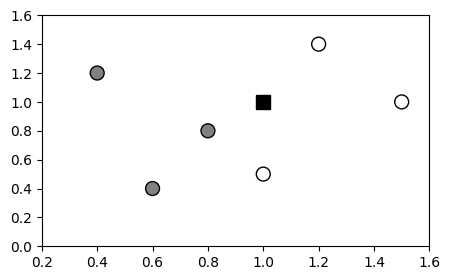

In [10]:
from scipy.spatial import distance
import statistics
import matplotlib.pyplot as plt
import numpy as np

def knn(x_train, y_train, x_test, k):
    distances = [] #lista que armazena as distâncias
    x1 = x_test # elemento a ser classificado
    for x2 in x_train: # distancia entre a observacao elementos no conjunto de teste
        dist = distance.euclidean(x1,x2)
        distances.append(dist)
    indices = []
    cl = []
    for i in range(0,k):
        ind = np.argmin(distances) #elemento no conjunto de teste mais proximo
        #print('distance:', distances[ind],'index:', ind, 'class:', y_train[ind])
        distances[ind] = np.max(distances)
        indices.append(ind)
        cl.append(y_train[ind]) #guarda a classe
    print("Classes:",cl)
    classification = statistics.mode(cl)# encontra a classe
    return classification

k = 3 # numero de vizinhos
x_train = np.array([[1,0.5],[0.8,0.8],[1.2,1.4],[0.6,0.4],[0.4,1.2],[1.5,1]])
y_train = np.array(['white','gray','white','gray','gray','white'], dtype = 'str')
x_test = np.array([1,1])
# realiza a classificacao
cl = knn(x_train, y_train, x_test, k)
print("Classification:", cl)
# mostra os dados
plt.figure(figsize=(5,3))
plt.scatter(x_train[:,0],x_train[:,1],c=y_train, s=100, marker='o', edgecolor='black')
plt.plot(x_test[0],x_test[1], marker='s', markersize=10, color="black")
plt.xlim(0.2,1.6)
plt.ylim(0,1.6)
plt.show(True)

A região de separação definida pelo algoritmo forma células de Voronoi, como mostrado a seguir.

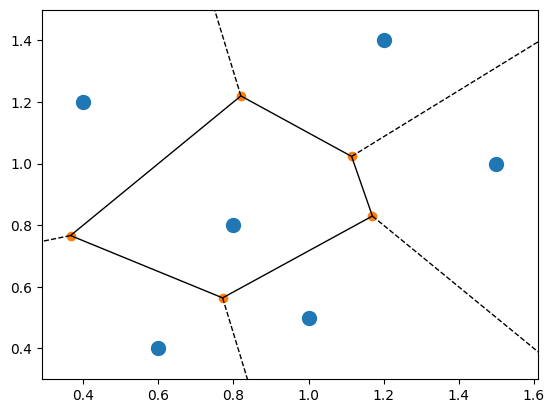

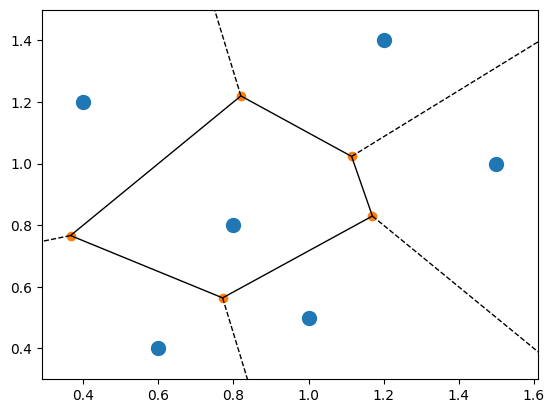

In [11]:
from scipy.spatial import Voronoi, voronoi_plot_2d
vor = Voronoi(x_train)
voronoi_plot_2d(vor,point_size=20)

## Região de decisão

Selecionando dois atributos, podemos visualizar a região de decisão. Para graficar a região de separação, precisamos instalar a bibliteca mlxtend: http://rasbt.github.io/mlxtend/installation/<br>
Pode ser usado: conda install -c conda-forge mlxtend

Para o método k-vizinhos mais próximos:

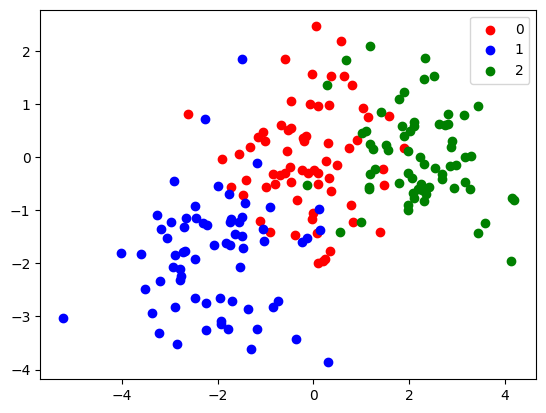

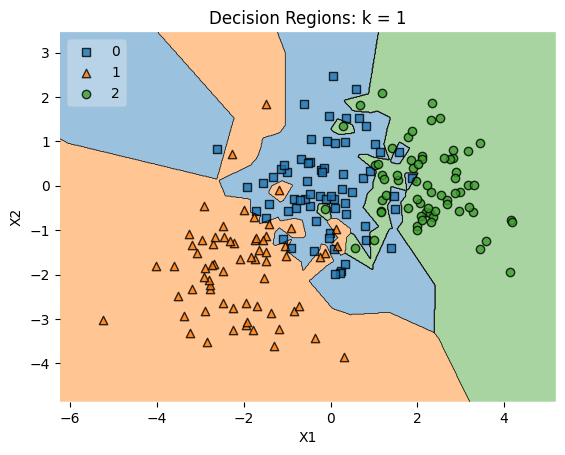

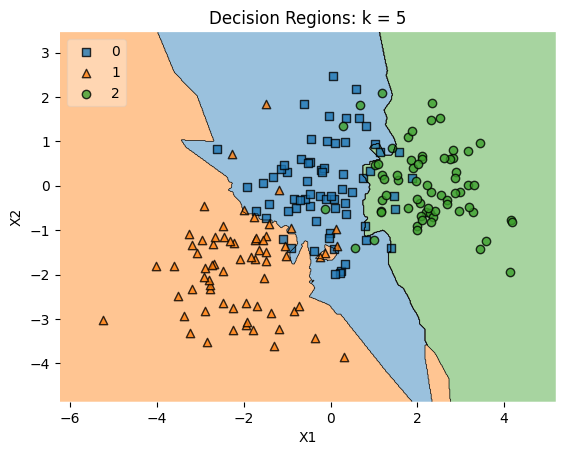

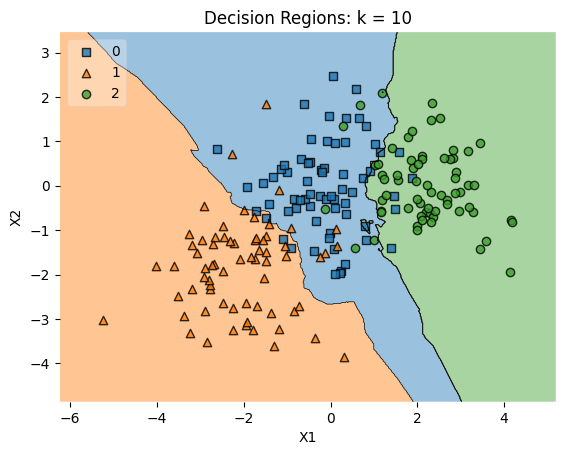

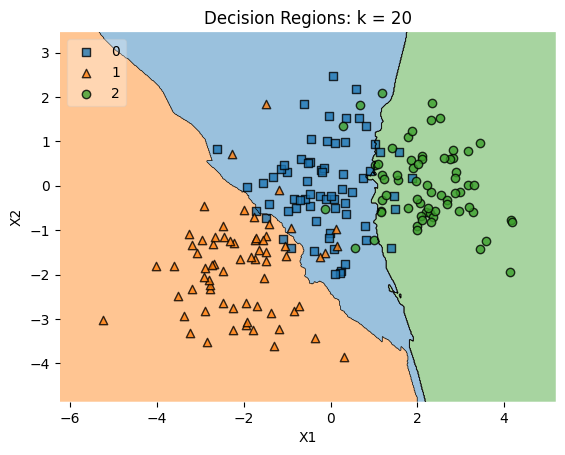

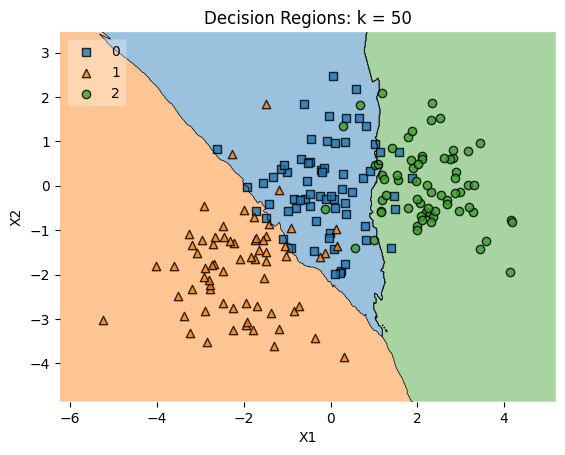

In [12]:
from mlxtend.plotting import plot_decision_regions
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
import sklearn.datasets as skdata
from matplotlib import pyplot
from pandas import DataFrame

# Gera os dados em duas dimensões
n_samples = 100 # número de observações
# centro dos grupos
centers = [(0, 0), (-2, -2), (2,0)]
X, y = skdata.make_blobs(n_samples=200, n_features=2, cluster_std=1.0, centers=centers,
                         shuffle=False, random_state=42)

# monta a matrix de atributos
d = np.column_stack((X,np.transpose(y)))
# converte para o formato dataframe do Pandas
data = DataFrame(data = d, columns=['X1', 'X2', 'y'])
features_names = ['X1', 'X2']
class_labels = np.unique(y)

# mostra os dados e colori de acordo com as classes
colors = ['red', 'blue', 'green', 'black']
aux = 0
for c in class_labels:
    ind = np.where(y == c)
    plt.scatter(X[ind,0][0], X[ind,1][0], color = colors[aux], label = c)
    aux = aux + 1
plt.savefig('knn_ex.eps')
plt.legend()
plt.show()

# mostra as regiões de separação para diversos valores de k
vk = [1,5,10,20,int(n_samples/2)]
for k in vk:
    # Training a classifier
    model = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
    model.fit(X, y)
    # Plotting decision regions
    plot_decision_regions(X, y, clf=model, legend=2)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Decision Regions: k = '+str(k))
    plt.show()

 Escolha do melhor $k$

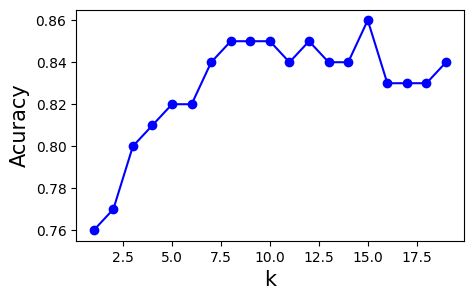

Melhor k: 15


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
import sklearn.datasets as skdata
from pandas import DataFrame
from sklearn.model_selection import cross_validate


# Gera os dados em duas dimensões
n_samples = 100 # número de observações
# centro dos grupos
centers = [(0, 0), (-2, -2), (2,0)]
X, y = skdata.make_blobs(n_samples=100, n_features=2, cluster_std=1.0, centers=centers,
                         shuffle=False, random_state=42)

# monta a matrix de atributos
d = np.column_stack((X,np.transpose(y)))
# converte para o formato dataframe do Pandas
data = DataFrame(data = d, columns=['X1', 'X2', 'y'])
features_names = ['X1', 'X2']
class_labels = np.unique(y)

nkf = 5 #number of folds
vk = [] # armazena os valores de k
vscore = []
for k in range(1, 20):
    model = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
    # realiza a validação cruzada
    cv = cross_validate(model, X, y, cv=nkf)
    #print('k:', k, 'accurace:', cv['test_score'].mean())
    vscore.append(cv['test_score'].mean())
    vk.append(k)

plt.figure(figsize=(5,3))
plt.plot(vk, vscore, '-bo')
plt.xlabel('k', fontsize = 15)
plt.ylabel('Acuracy', fontsize = 15)
plt.show(True)
best_k = np.argmax(vscore)+1
print('Melhor k:', best_k)

In [14]:
data.head()

,X1,X2,y
0,0.496714,-0.138264,0.0
1,0.647689,1.523030,0.0
2,-0.234153,-0.234137,0.0
3,1.579213,0.767435,0.0
4,-0.469474,0.542560,0.0


## Métricas

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
import sklearn.datasets as skdata
from pandas import DataFrame
from sklearn.model_selection import cross_validate


# Gera os dados em duas dimensões
n_samples = 100 # número de observações
# centro dos grupos
centers = [(0, 0), (-2, -2), (2,0)]
X, y = skdata.make_blobs(n_samples=100, n_features=2, cluster_std=1.5, centers=centers,
                         shuffle=False, random_state=42)

# monta a matrix de atributos
d = np.column_stack((X,np.transpose(y)))
# converte para o formato dataframe do Pandas
data = DataFrame(data = d, columns=['X1', 'X2', 'y'])
features_names = ['X1', 'X2']
class_labels = np.unique(y)

nkf = 5 #number of folds
vk = [] # armazena os valores de k
vscore = []
vm = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
for d in vm:
    model = KNeighborsClassifier(n_neighbors=k, metric = d)
    # realiza a validação cruzada
    cv = cross_validate(model, X, y, cv=nkf)
    #print('k:', k, 'accurace:', cv['test_score'].mean())
    print(d,':', cv['test_score'].mean())

euclidean : 0.66
manhattan : 0.69
chebyshev : 0.6900000000000001
minkowski : 0.66


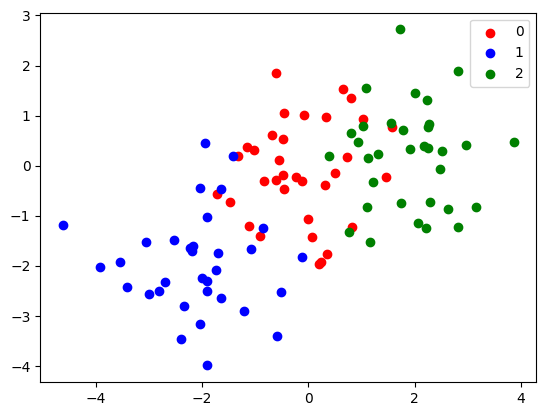

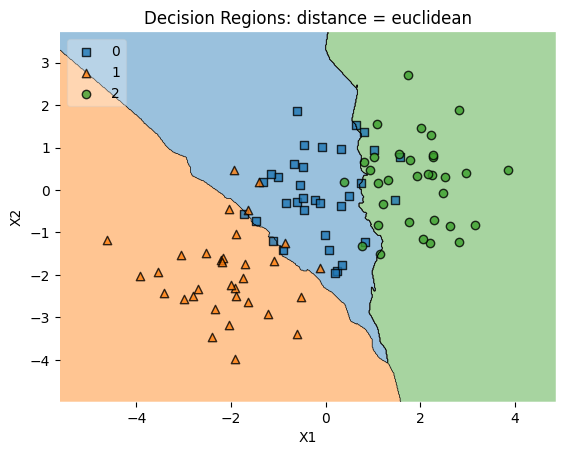

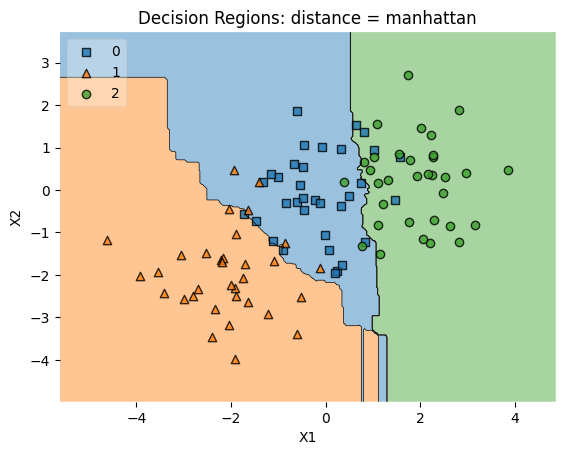

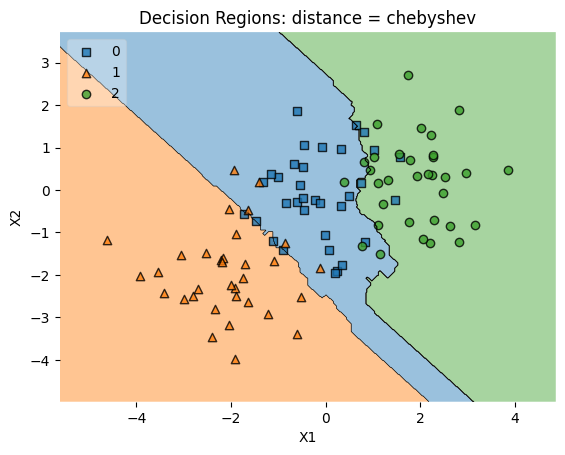

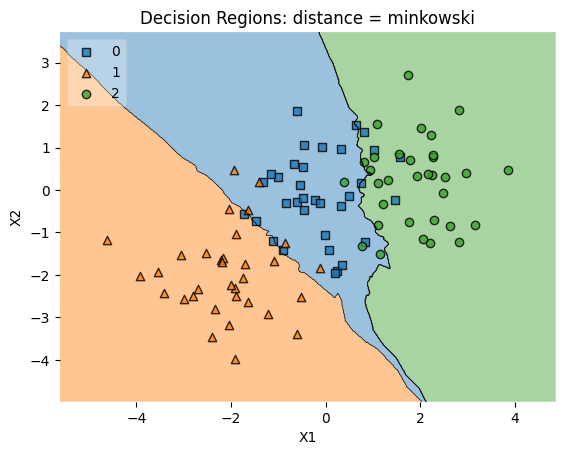

In [16]:
from mlxtend.plotting import plot_decision_regions
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
import sklearn.datasets as skdata
from matplotlib import pyplot
from pandas import DataFrame

# Gera os dados em duas dimensões
n_samples = 100 # número de observações
# centro dos grupos
centers = [(0, 0), (-2, -2), (2,0)]
X, y = skdata.make_blobs(n_samples=100, n_features=2, cluster_std=1.0, centers=centers,
                         shuffle=False, random_state=42)

# monta a matrix de atributos
d = np.column_stack((X,np.transpose(y)))
# converte para o formato dataframe do Pandas
data = DataFrame(data = d, columns=['X1', 'X2', 'y'])
features_names = ['X1', 'X2']
class_labels = np.unique(y)

# mostra os dados e colori de acordo com as classes

colors = ['red', 'blue', 'green', 'black']
aux = 0
for c in class_labels:
    ind = np.where(y == c)
    plt.scatter(X[ind,0][0], X[ind,1][0], color = colors[aux], label = c)
    aux = aux + 1
plt.legend()
plt.show()

# mostra as regiões de separação para diversos valores de k
vm = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
k = 21
for d in vm:
    # Training a classifier
    model = KNeighborsClassifier(n_neighbors=k, metric = d, p=3)
    model.fit(X, y)
    # Plotting decision regions
    plot_decision_regions(X, y, clf=model, legend=2)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('Decision Regions: distance = '+ d)
    #plt.savefig('knn_' + str(d)+'.eps')
    plt.show()

## Classificação de dados

Vamos inicialmente ler os dados:

In [17]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
np.random.seed(10)

drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))
data = pd.read_csv('/content/drive/My Drive/dados/winequality-red.csv', header=(0))


data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

nrow, ncol = data.shape
print("Matriz de atributos: Número de linhas:", nrow, " colunas: ", ncol)
attributes = list(data.columns)
data.head(10)

Mounted at /content/drive/
Matriz de atributos: Número de linhas: 1599  colunas:  12


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


Vamos construir as variáveis $X$ e $y$, sendo que o processo classificação se resume em estimar a função $f$ na relação $y = f(X) + \epsilon$, onde $\epsilon$ é o erro, que tem distribuição normal com média igual a zero e variância $\sigma^2$.

Convertemos os dados para o formato Numpy para facilitar a sua manipulação.

In [18]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

Para treinar o classificador, precisamos definir o conjunto de teste e treinamento.

In [19]:
from sklearn.model_selection import train_test_split
p = 0.7
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size = p, random_state = 42)

Vamos normalizar os dados, de modo a evitar o efeito da escala dos atributos.

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

A partir desse conjunto de dados, podemos realizar a classificação.

Para realizar a classificação, vamos usar a biblioteca scikit-learn (https://scikit-learn.org). É possível implementar o método usando métricas diferentes da Euclidiana, como as que podem ser vistas em: https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.DistanceMetric.html

Vamos ajustar o modelo. Inicialmente, vamos considerar o método hold-out para selecionar o conjunto de teste e treinamento, que seleciona uma fração p de elementos para o conjunto de teste e (1-p), para treinamento. A seleção do modelo será feita mais adiante usando validação cruzada.

Relizando a classificação pelo método dos k-vizinhos:

In [21]:
from sklearn.neighbors import KNeighborsClassifier
k = 5 # numero de vizinhos
# ajusta o modelo k-vizinhos
model = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
model.fit(X_train,y_train)
# faz a predição no conjunto de teste
y_pred = model.predict(X_test)

O erro na classificação pode ser quantificado pela medida de acurácia.

In [22]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_pred, y_test)
print('Accuracy:', score)

Accuracy: 0.5708333333333333


Notem quem o valor da acurácia depende do número de vizinhos $k$. Podemos selecionar o melhor valor de $k$ usando validação cruzada.

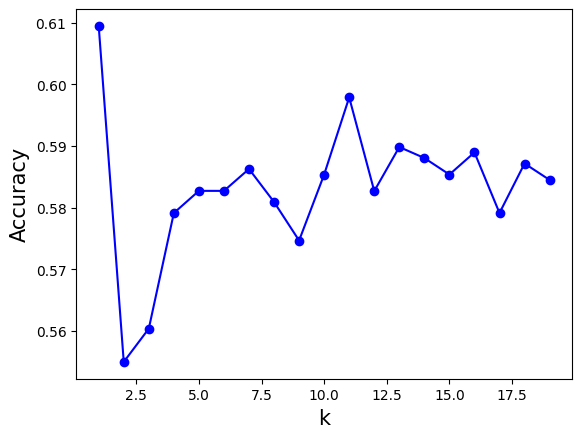

Melhor k: 1


In [23]:
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier

nkf = 5 #number of folds
vk = [] # armazena os valores de k
vscore = []
for k in range(1, 20):
    model = KNeighborsClassifier(n_neighbors=k, metric = 'euclidean')
    # realiza a validação cruzada
    cv = cross_validate(model, X_train, y_train, cv=nkf)
    #print('k:', k, 'accurace:', cv['test_score'].mean())
    vscore.append(cv['test_score'].mean())
    vk.append(k)

plt.plot(vk, vscore, '-bo')
plt.xlabel('k', fontsize = 15)
plt.ylabel('Accuracy', fontsize = 15)
plt.show(True)
best_k = np.argmax(vscore)+1
print('Melhor k:', best_k)

Usando todo o conjunto de treinamento, podemos ajustar o modelo e realizar a classificação no conjunto de teste.

In [24]:
from sklearn.metrics import accuracy_score
model = KNeighborsClassifier(n_neighbors=best_k, metric = 'euclidean')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('Accuracy:', accuracy_score(y_pred, y_test))

Accuracy: 0.6229166666666667


Podemos fazer a classificação de forma automática com o método GridSearchCV.

In [25]:
from sklearn.model_selection import GridSearchCV

# Define o modelo
model = KNeighborsClassifier()

# Define os parâmetros a serem testados
param_grid = {'n_neighbors': range(1, 20),
              'metric': ['euclidean', 'manhattan']}

# Cria o objeto GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=5)

# Treina o modelo com os parâmetros definidos
grid_search.fit(X_train, y_train)

# Imprime os melhores parâmetros encontrados
print("Melhores parâmetros:", grid_search.best_params_)

# Imprime a melhor pontuação encontrada
print("Melhor pontuação:", grid_search.best_score_)

# Usa o melhor modelo para fazer previsões
y_pred = grid_search.predict(X_test)

# Avalia o modelo
print('Accuracy:', accuracy_score(y_pred, y_test))

Melhores parâmetros: {'metric': 'euclidean', 'n_neighbors': 1}
Melhor pontuação: 0.6094811018577835
Accuracy: 0.6229166666666667


## Regressão Logística

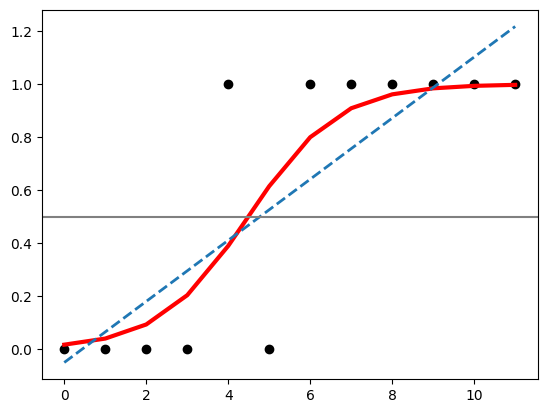

In [26]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import linear_model
from scipy.special import expit

X = np.arange(12).reshape(-1, 1)
y = np.array([0, 0, 0, 0,1,0, 1, 1, 1, 1, 1, 1])
plt.plot(X, y, 'ko')

# Ajusta o modelo de regressao logistica
model = linear_model.LogisticRegression()
model.fit(X, y)
loss = expit(X * model.coef_ + model.intercept_).ravel()
plt.plot(X, loss, color='red', linewidth=3)

# Podemos obter uma curva mais suave
#xx = np.arange(min(X), max(X), 0.01)
#loss = expit(xx * model.coef_ + model.intercept_).ravel()
#plt.plot(xx, loss, color='red', linewidth=3)

# Ajusta um modelo de regressao linear
linear = linear_model.LinearRegression()
linear.fit(X, y)
plt.plot(X, linear.coef_ * X + linear.intercept_, linewidth=2, linestyle='dashed')
plt.axhline(.5, color='.5')
plt.show(True)

In [27]:
p = model.predict_proba(X)
print(p)

[[0.98403244 0.01596756]
 [0.96096688 0.03903312]
 [0.90770748 0.09229252]
 [0.7971197  0.2028803 ]
 [0.6108338  0.3891662 ]
 [0.38538531 0.61461469]
 [0.20031573 0.79968427]
 [0.09096634 0.90903366]
 [0.03843983 0.96156017]
 [0.01571912 0.98428088]
 [0.00633945 0.99366055]
 [0.00254222 0.99745778]]


In [28]:
print("Acurácia:", model.score(X, y))

Acurácia: 0.8333333333333334


Código completo:

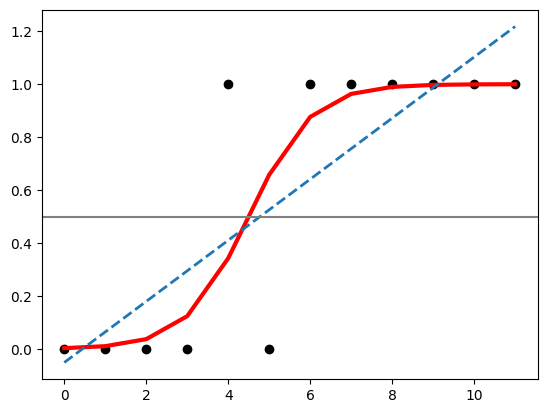

Acurácia: 0.8333333333333334


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from scipy.special import expit

X = np.arange(12).reshape(-1, 1)
y = np.array([0, 0, 0, 0,1,0, 1, 1, 1, 1, 1, 1])
plt.plot(X, y, 'ko')

# Ajusta o modelo de regressao logistica
model = linear_model.LogisticRegression(C=1e5)
model.fit(X, y)
loss = expit(X * model.coef_ + model.intercept_).ravel()
plt.plot(X, loss, color='red', linewidth=3)

# Para comparar, ajustamos um modelo de regressao linear
linear = linear_model.LinearRegression()
linear.fit(X, y)
plt.plot(X, linear.coef_ * X + linear.intercept_, linewidth=2, linestyle='dashed')
plt.axhline(.5, color='.5')
plt.show(True)

p = model.predict_proba(X)
print("Acurácia:", model.score(X, y))

Vamos considerar um conjunto de dados.

In [30]:
import random
random.seed(42) # define the seed (important to reproduce the results)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
np.random.seed(10)

drive.mount('/content/drive/')
#data = pd.read_csv('/content/drive/My Drive/dados/Vehicle.csv', header=(0))
data = pd.read_csv('/content/drive/My Drive/dados/winequality-red.csv', header=(0))

data = data.dropna(axis='rows') #remove NaN
# armazena os nomes das classes
classes = np.array(pd.unique(data[data.columns[-1]]), dtype=str)

print("Número de linhas e colunas na matriz de atributos:", data.shape)
attributes = list(data.columns)
data.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Número de linhas e colunas na matriz de atributos: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [31]:
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

In [32]:
from sklearn.model_selection import train_test_split
p = 0.2 # fraction of elements in the test set
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = p, random_state = 42)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

model = LogisticRegression(solver = 'lbfgs', multi_class = 'auto', max_iter = 10000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print('Acurácia: ', model.score(x_test, y_test))

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Acurácia:  0.571875


Fazendo o ajuste dos hiperparâmetros:

In [39]:
# prompt: use gridsearchcv

# Define the model
model = LogisticRegression()

# Define the parameter grid to search
param_grid = {
    'solver': ['newton-cg', 'lbfgs'],
    'C': [0.001, 0.01, 0.1, 1, 10],
    #'penalty': ['l1', 'l2'],
    'max_iter': [20000]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(model, param_grid, cv=5)

# Fit the model with the defined parameters
grid_search.fit(x_train, y_train)

# Print the best parameters found
print("Best parameters:", grid_search.best_params_)

# Print the best score found
print("Best score:", grid_search.best_score_)

# Use the best model to make predictions
y_pred = grid_search.predict(x_test)

# Evaluate the model
print('Accuracy:', accuracy_score(y_pred, y_test))

Best parameters: {'C': 1, 'max_iter': 20000, 'solver': 'lbfgs'}
Best score: 0.6130361519607843
Accuracy: 0.571875


Região de separação.

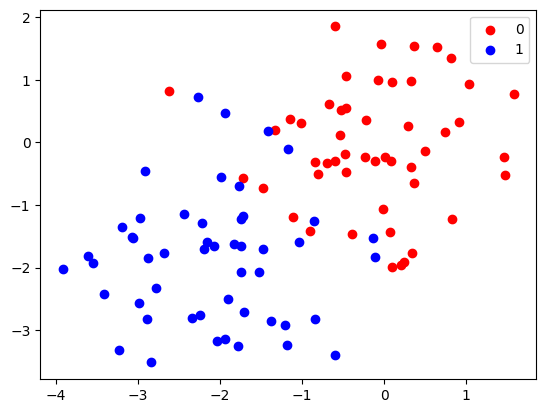

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


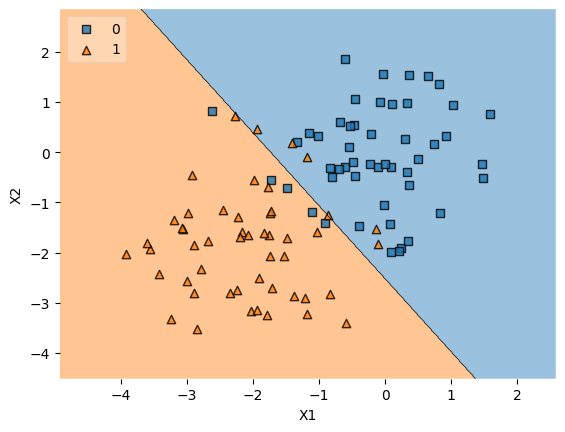

In [35]:
from mlxtend.plotting import plot_decision_regions
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
import sklearn.datasets as skdata
from matplotlib import pyplot
from pandas import DataFrame

# Gera os dados em duas dimensões
n_samples = 100 # número de observações
# centro dos grupos
#centers = [(0, 0), (-2, -2), (2,0)]
centers = [(0, 0), (-2, -2)]
X, y = skdata.make_blobs(n_samples=100, n_features=2, cluster_std=1.0, centers=centers,
                         shuffle=False, random_state=42)

# monta a matrix de atributos
d = np.column_stack((X,np.transpose(y)))
# converte para o formato dataframe do Pandas
data = DataFrame(data = d, columns=['X1', 'X2', 'y'])
features_names = ['X1', 'X2']
class_labels = np.unique(y)

# mostra os dados e colori de acordo com as classes
colors = ['red', 'blue', 'green', 'black']
aux = 0
for c in class_labels:
    ind = np.where(y == c)
    plt.scatter(X[ind,0][0], X[ind,1][0], color = colors[aux], label = c)
    aux = aux + 1
plt.legend()
plt.show()

# Training a classifier
model = LogisticRegression(solver = 'lbfgs', multi_class = 'auto', max_iter = 1000)
model.fit(X, y)
# Plotting decision regions
plot_decision_regions(X, y, clf=model, legend=2)
plt.xlabel('X1')
plt.ylabel('X2')
#plt.savefig('logistic-region.eps')
plt.show()

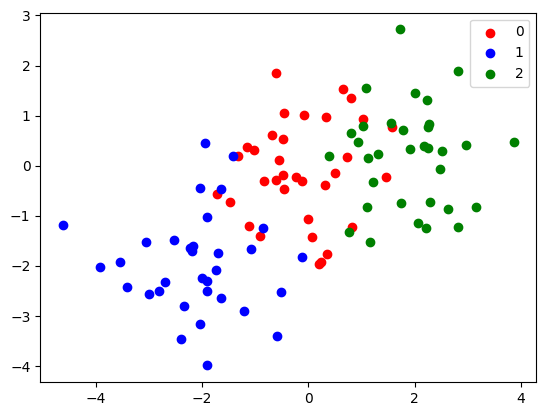

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


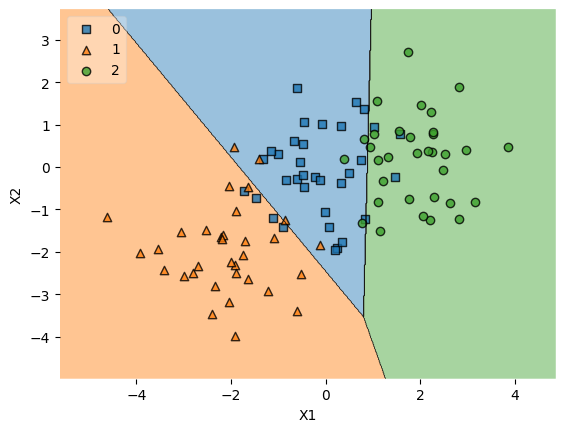

In [36]:
from mlxtend.plotting import plot_decision_regions
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.linear_model import LogisticRegression
import sklearn.datasets as skdata
from matplotlib import pyplot
from pandas import DataFrame

# Gera os dados em duas dimensões
n_samples = 100 # número de observações
# centro dos grupos
centers = [(0, 0), (-2, -2), (2,0)]
X, y = skdata.make_blobs(n_samples=100, n_features=2, cluster_std=1.0, centers=centers,
                         shuffle=False, random_state=42)

# monta a matrix de atributos
d = np.column_stack((X,np.transpose(y)))
# converte para o formato dataframe do Pandas
data = DataFrame(data = d, columns=['X1', 'X2', 'y'])
features_names = ['X1', 'X2']
class_labels = np.unique(y)

# mostra os dados e colori de acordo com as classes
colors = ['red', 'blue', 'green', 'black']
aux = 0
for c in class_labels:
    ind = np.where(y == c)
    plt.scatter(X[ind,0][0], X[ind,1][0], color = colors[aux], label = c)
    aux = aux + 1
plt.legend()
plt.show()

# Training a classifier
model = LogisticRegression(solver = 'lbfgs', multi_class = 'auto', max_iter = 1000)
model.fit(X, y)
# Plotting decision regions
plot_decision_regions(X, y, clf=model, legend=2)
plt.xlabel('X1')
plt.ylabel('X2')
#plt.savefig('logistic-region.eps')
plt.show()